<a href="https://colab.research.google.com/github/Clover130/EMSC2010-W7-L1/blob/main/EMSC2010_W7_P1_NB1_u8229609.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010-W7-P1-NB1

We will test if the air pressures inside and outside the building are the same.

The whole class will collect data using Phyphox (see the *Pressure* option), with each person measuring one inside pressure and one outside pressure. These data will be our measured air pressure samples.

Use the ```PyMC``` code we developed in the previous session (see notebook ```EMSC2010-W7-L1-NB3``` to estimate the posterior distributions for the mean atmospheric pressures inside and outside the building.

In [1]:
import pymc as pm
import arviz as az
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
data_in = np.array([965.784,965.07,965.50,965.993,965.765,965.786,955.604,965.057,965.50,965.390,965.302,965.921,963.623,965.388,965.5,965.910,965.564,965.893,965.735,965.537])
data_out = np.array([966.176,965.453,966.25,966.363,966.15,966.085,965.649,965.414,966.172,965.750,965.673,966.257,964.034,965.763,965.85,966.264,966.111,965.864,966.251,965.867])
plt.hist(data_out)

##Priors
Air Pressure:
- not negative
- narrow to atmospheric pressure (1013 Ha, average at sea level)
- decreases with elevation

Same prior for both

<Axes: title={'center': 'mu'}>

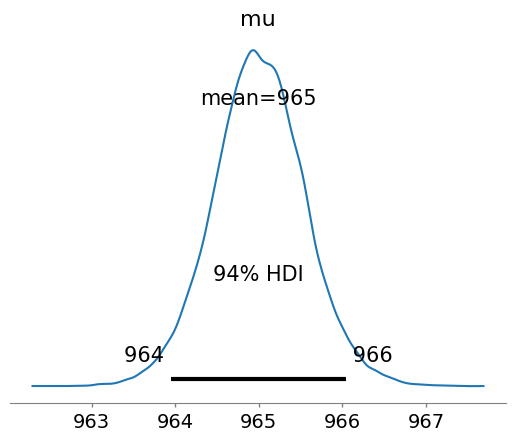

In [23]:
with pm.Model() as airpressure_inside_model:

    # Prior for the mean: sigma reflects level of ignorance
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std: leave it broad
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_in)

    # Obtain 20,000 samples from the posterior
    trace_in = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_in, var_names=["mu"])

## does two runs to check if it reaches convergence (will flag if it doesn't, ie. if divergence happens)

<Axes: title={'center': 'mu'}>

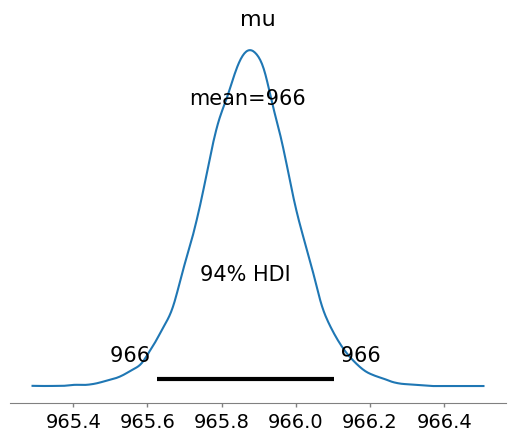

In [22]:
from pymc.progress_bar import progress
with pm.Model() as airpressure_outside_model:

    # Prior for the mean: sigma reflects level of ignorance
    mu = pm.Normal("mu", mu=1000, sigma=100)

    # Prior for std: leave it broad
    sigma = pm.HalfNormal("sigma", sigma=20)

    # Likelihood given the data
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=data_out)

    # Obtain 20,000 samples from the posterior
    trace_out = pm.sample(20000, tune=2000, return_inferencedata=True, progressbar=False)

#plot the posterior distribution for the mean
az.plot_posterior(trace_out, var_names=["mu"])


##Compare Posteriors
Subtract one distribution from another, would equal 0 if equal

Subtract via monte carlo (draw random number from each and subtract, repeat)

In [15]:
# Extract the posterior samples as a numpy array
mu_samples_in = trace_in.posterior["mu"].values.flatten() ## extract posterior for the mean from the trace (already defined as mu in model), get values, flatten into one column
mu_samples_out = trace_out.posterior["mu"].values.flatten()

Text(0.5, 0, 'Pressure difference inside-outside [hPa]')

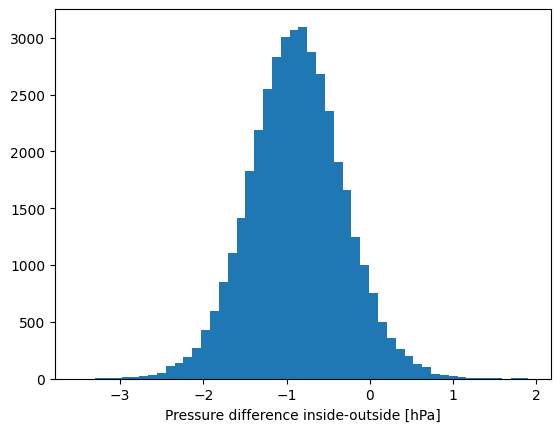

In [17]:
# Subtracts one column from the other
mu_diff = mu_samples_in - mu_samples_out
plt.hist(mu_diff, bins=51)
plt.xlabel('Pressure difference inside-outside [hPa]')

In [20]:
az.hdi(mu_diff,hdi_prob=0.95) # hdi = highest density interval

array([-2.01569393,  0.22751377])

From priors and posterior there is a 95% probability the difference in air pressure if 0, conclude there is no air pressure difference
- because 0 is in the 95% highest density interval